/Users/thompsong/miniforge3/envs/flovopy_asl/lib/python3.12/site-packages/contextily/tile.py:662: UserWarning: The inferred zoom level of 20 is not valid for the current tile provider (valid zooms: 0 - 19).
  warnings.warn(msg)


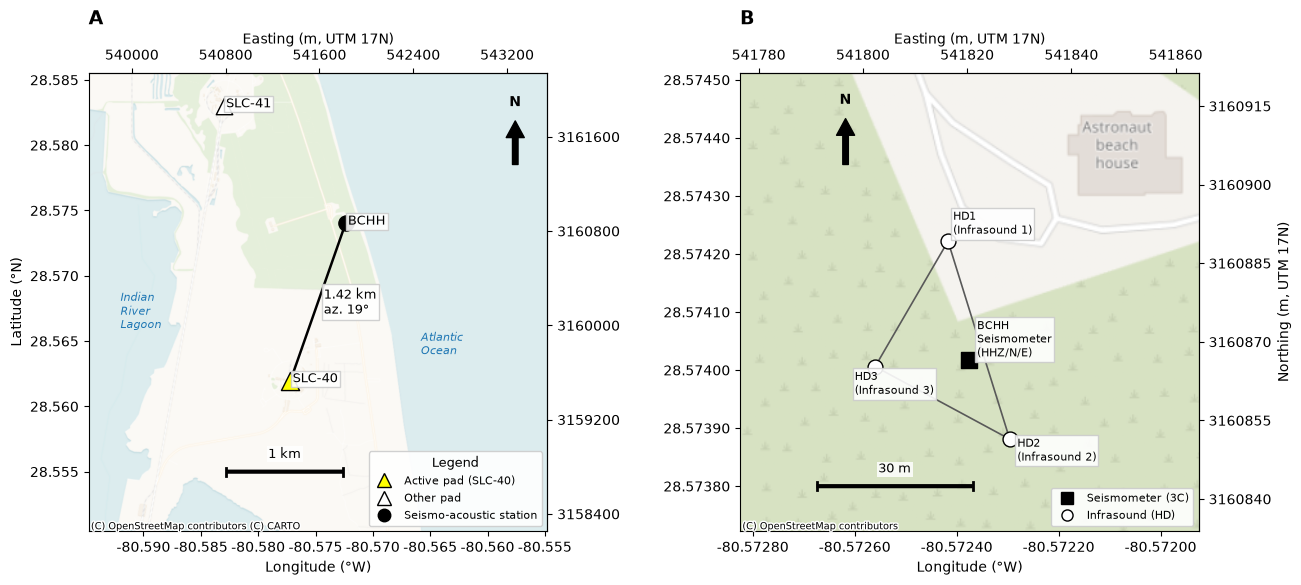

In [1]:
#!/usr/bin/env python3
"""
Generate Falcon 9 BCHH location figure.

Creates:
  fig01_slc40_bchh_location.png
  fig01_slc40_bchh_location.pdf
"""

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import contextily as cx

from shapely.geometry import Point, LineString
from pyproj import Geod, Transformer


OUTDIR = Path("figures")
OUTDIR.mkdir(exist_ok=True)

# ------------------------------------------------------------
# Coordinates
# ------------------------------------------------------------

SLC40 = dict(name="SLC-40", lat=28.56195, lon=-80.57719)
SLC41 = dict(name="SLC-41", lat=28.5830, lon=-80.5830)  # approximate; replace if needed

BCHH_SENSORS = pd.DataFrame(
    [
        ["Seismometer", "BCHH\nSeismometer\n(HHZ/N/E)", 541820.43, 3160866.50, 28.5740171, -80.572375],
        ["HD1", "HD1\n(Infrasound 1)", 541816.30, 3160889.14, 28.574222, -80.572417],
        ["HD2", "HD2\n(Infrasound 2)", 541828.28, 3160851.47, 28.573881, -80.572296],
        ["HD3", "HD3\n(Infrasound 3)", 541802.34, 3160865.25, 28.574006, -80.572560],
    ],
    columns=["sensor", "label", "easting", "northing", "lat", "lon"],
)

BCHH = dict(
    name="BCHH",
    lat=float(BCHH_SENSORS.loc[BCHH_SENSORS.sensor == "Seismometer", "lat"].iloc[0]),
    lon=float(BCHH_SENSORS.loc[BCHH_SENSORS.sensor == "Seismometer", "lon"].iloc[0]),
)

GEOD = Geod(ellps="WGS84")
to_utm = Transformer.from_crs("EPSG:4326", "EPSG:32617", always_xy=True)


# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------

def add_basemap(ax):
    cx.add_basemap(
        ax,
        source=cx.providers.CartoDB.Positron,
        attribution_size=7,
        alpha=0.78,
    )


def setup_dual_axes(ax, lonlim, latlim):
    ax.set_xlim(lonlim)
    ax.set_ylim(latlim)

    ax.set_xlabel("Longitude (°W)")
    ax.set_ylabel("Latitude (°N)")

    def lon_to_easting(lon):
        lon = np.asarray(lon)
        lat_mid = np.mean(latlim)
        e, _ = to_utm.transform(lon, np.full_like(lon, lat_mid, dtype=float))
        return e

    def easting_to_lon(e):
        e = np.asarray(e)
        lat_mid = np.mean(latlim)
        # approximate inverse through pyproj
        from pyproj import Transformer
        inv = Transformer.from_crs("EPSG:32617", "EPSG:4326", always_xy=True)
        lon, _ = inv.transform(e, np.full_like(e, np.mean([lon_to_northing(lonlim[0]), lon_to_northing(lonlim[1])])))
        return lon

    def lat_to_northing(lat):
        lat = np.asarray(lat)
        lon_mid = np.mean(lonlim)
        _, n = to_utm.transform(np.full_like(lat, lon_mid, dtype=float), lat)
        return n

    def northing_to_lat(n):
        n = np.asarray(n)
        lon_mid = np.mean(lonlim)
        e_mid, _ = to_utm.transform(lon_mid, np.mean(latlim))
        from pyproj import Transformer
        inv = Transformer.from_crs("EPSG:32617", "EPSG:4326", always_xy=True)
        _, lat = inv.transform(np.full_like(n, e_mid, dtype=float), n)
        return lat

    ax_top = ax.secondary_xaxis("top", functions=(lon_to_easting, easting_to_lon))
    ax_top.set_xlabel("Easting (m, UTM 17N)")

    ax_right = ax.secondary_yaxis("right", functions=(lat_to_northing, northing_to_lat))
    ax_right.set_ylabel("Northing (m, UTM 17N)")

    return ax_top, ax_right


def add_scalebar_lonlat(ax, lon, lat, length_m, label):
    lon2, lat2, _ = GEOD.fwd(lon, lat, 90, length_m)

    ax.plot([lon, lon2], [lat, lat2], "k-", lw=3, solid_capstyle="butt", zorder=20)
    ax.plot([lon, lon], [lat - 0.00015, lat + 0.00015], "k-", lw=2, zorder=20)
    ax.plot([lon2, lon2], [lat - 0.00015, lat + 0.00015], "k-", lw=2, zorder=20)
    ax.text(
        (lon + lon2) / 2,
        lat + 0.00035,
        label,
        ha="center",
        va="bottom",
        fontsize=9,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.85, pad=1),
        zorder=21,
    )


def add_north_arrow(ax, lon, lat, length_m=350):
    lon2, lat2, _ = GEOD.fwd(lon, lat, 0, length_m)
    ax.annotate(
        "",
        xy=(lon2, lat2),
        xytext=(lon, lat),
        arrowprops=dict(facecolor="black", edgecolor="black", width=4, headwidth=13),
        zorder=30,
    )
    ax.text(lon2, lat2 + 0.00035, "N", ha="center", va="bottom", fontsize=10, fontweight="bold")


def label(ax, lon, lat, text, dx=0.0002, dy=0.00015, size=9):
    ax.text(
        lon + dx,
        lat + dy,
        text,
        fontsize=size,
        ha="left",
        va="center",
        bbox=dict(facecolor="white", edgecolor="0.8", alpha=0.9, pad=1.5),
        zorder=30,
    )


# COrrections
from pyproj import Transformer
import numpy as np
import contextily as cx

LL_TO_UTM = Transformer.from_crs("EPSG:4326", "EPSG:32617", always_xy=True)
UTM_TO_LL = Transformer.from_crs("EPSG:32617", "EPSG:4326", always_xy=True)

def add_basemap(ax):
    cx.add_basemap(
        ax,
        source=cx.providers.CartoDB.Positron,
        crs="EPSG:4326",          # IMPORTANT because axes are lon/lat
        reset_extent=False,
        attribution_size=7,
        alpha=0.78,
    )

def setup_dual_axes(ax, lonlim, latlim):
    ax.set_xlim(lonlim)
    ax.set_ylim(latlim)

    ax.set_xlabel("Longitude (°W)")
    ax.set_ylabel("Latitude (°N)")

    lon_mid = float(np.mean(lonlim))
    lat_mid = float(np.mean(latlim))
    e_mid, n_mid = LL_TO_UTM.transform(lon_mid, lat_mid)

    def lon_to_easting(lon):
        lon = np.asarray(lon, dtype=float)
        e, _ = LL_TO_UTM.transform(lon, np.full_like(lon, lat_mid))
        return e

    def easting_to_lon(e):
        e = np.asarray(e, dtype=float)
        lon, _ = UTM_TO_LL.transform(e, np.full_like(e, n_mid))
        return lon

    def lat_to_northing(lat):
        lat = np.asarray(lat, dtype=float)
        _, n = LL_TO_UTM.transform(np.full_like(lat, lon_mid), lat)
        return n

    def northing_to_lat(n):
        n = np.asarray(n, dtype=float)
        _, lat = UTM_TO_LL.transform(np.full_like(n, e_mid), n)
        return lat

    ax_top = ax.secondary_xaxis("top", functions=(lon_to_easting, easting_to_lon))
    ax_top.set_xlabel("Easting (m, UTM 17N)")

    ax_right = ax.secondary_yaxis("right", functions=(lat_to_northing, northing_to_lat))
    ax_right.set_ylabel("Northing (m, UTM 17N)")

    return ax_top, ax_right

from matplotlib.ticker import FormatStrFormatter, FuncFormatter, MaxNLocator

def add_basemap(ax, provider="voyager", alpha=0.90):
    if provider == "osm":
        source = cx.providers.OpenStreetMap.Mapnik
    elif provider == "voyager":
        source = cx.providers.CartoDB.Voyager
    else:
        source = cx.providers.CartoDB.Positron

    cx.add_basemap(
        ax,
        source=source,
        crs="EPSG:4326",
        reset_extent=False,
        attribution_size=7,
        alpha=alpha,
    )


def plain_utm_formatter(x, pos):
    return f"{x:.0f}"


def setup_dual_axes(
    ax,
    lonlim,
    latlim,
    lonfmt="%.3f",
    latfmt="%.3f",
    xlabel="Longitude (°W)",
    ylabel="Latitude (°N)",
    top_xlabel="Easting (m, UTM 17N)",
    right_ylabel="Northing (m, UTM 17N)",
):
    ax.set_xlim(lonlim)
    ax.set_ylim(latlim)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    ax.xaxis.set_major_formatter(FormatStrFormatter(lonfmt))
    ax.yaxis.set_major_formatter(FormatStrFormatter(latfmt))
    # old
    #ax.ticklabel_format(useOffset=False, style="plain", axis="both")
    # new
    ax.xaxis.get_offset_text().set_visible(False)
    ax.yaxis.get_offset_text().set_visible(False)

    lon_mid = float(np.mean(lonlim))
    lat_mid = float(np.mean(latlim))
    e_mid, n_mid = LL_TO_UTM.transform(lon_mid, lat_mid)

    def lon_to_easting(lon):
        lon = np.asarray(lon, dtype=float)
        e, _ = LL_TO_UTM.transform(lon, np.full_like(lon, lat_mid))
        return e

    def easting_to_lon(e):
        e = np.asarray(e, dtype=float)
        lon, _ = UTM_TO_LL.transform(e, np.full_like(e, n_mid))
        return lon

    def lat_to_northing(lat):
        lat = np.asarray(lat, dtype=float)
        _, n = LL_TO_UTM.transform(np.full_like(lat, lon_mid), lat)
        return n

    def northing_to_lat(n):
        n = np.asarray(n, dtype=float)
        _, lat = UTM_TO_LL.transform(np.full_like(n, e_mid), n)
        return lat

    ax_top = ax.secondary_xaxis("top", functions=(lon_to_easting, easting_to_lon))
    ax_top.set_xlabel(top_xlabel)
    ax_top.xaxis.set_major_formatter(FuncFormatter(plain_utm_formatter))
    ax_top.xaxis.set_major_locator(MaxNLocator(nbins=5, integer=True))

    ax_right = ax.secondary_yaxis("right", functions=(lat_to_northing, northing_to_lat))
    ax_right.set_ylabel(right_ylabel)
    ax_right.yaxis.set_major_formatter(FuncFormatter(plain_utm_formatter))
    ax_right.yaxis.set_major_locator(MaxNLocator(nbins=6, integer=True))

    return ax_top, ax_right


def add_north_arrow_axes(ax, xy=(0.93, 0.82), length=0.10):
    x, y = xy
    ax.annotate(
        "",
        xy=(x, y + length),
        xytext=(x, y),
        xycoords="axes fraction",
        arrowprops=dict(facecolor="black", edgecolor="black", width=4, headwidth=13),
        zorder=50,
        clip_on=False,
    )
    ax.text(
        x,
        y + length + 0.025,
        "N",
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        zorder=51,
    )


def add_scalebar_lonlat(ax, lon, lat, length_m, label):
    lon2, lat2, _ = GEOD.fwd(lon, lat, 90, length_m)

    # tick height proportional to map height
    y0, y1 = ax.get_ylim()
    tick_h = 0.018 * (y1 - y0)

    ax.plot([lon, lon2], [lat, lat2], "k-", lw=3, solid_capstyle="butt", zorder=40)
    ax.plot([lon, lon], [lat - tick_h / 2, lat + tick_h / 2], "k-", lw=2, zorder=40)
    ax.plot([lon2, lon2], [lat - tick_h / 2, lat + tick_h / 2], "k-", lw=2, zorder=40)

    ax.text(
        (lon + lon2) / 2,
        lat + 1.3 * tick_h,
        label,
        ha="center",
        va="bottom",
        fontsize=9,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.85, pad=1),
        zorder=41,
    )

def equal_scale_lonlat_limits(center_lon, center_lat, width_lon=None, height_lat=None):
    """
    Return lonlim, latlim with approximately equal ground scale on x/y axes.

    If width_lon is given, height_lat = width_lon * cos(latitude).
    If height_lat is given, width_lon = height_lat / cos(latitude).
    """
    c = np.cos(np.deg2rad(center_lat))

    if width_lon is None and height_lat is None:
        raise ValueError("Provide either width_lon or height_lat")

    if width_lon is not None:
        height_lat = width_lon * c
    else:
        width_lon = height_lat / c

    lonlim = (center_lon - width_lon / 2, center_lon + width_lon / 2)
    latlim = (center_lat - height_lat / 2, center_lat + height_lat / 2)
    return lonlim, latlim

# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------

#fig, axes = plt.subplots(1, 2, figsize=(12.5, 7.2), constrained_layout=True)
fig, axes = plt.subplots(1, 2, figsize=(12.2, 6.1))
fig.subplots_adjust(left=0.065, right=0.975, bottom=0.105, top=0.885, wspace=0.42)

# ---------------- Panel A ----------------

ax = axes[0]
ax.set_title("A", loc="left", fontsize=14, fontweight="bold")

'''
lonlim = (-80.586, -80.5625)
latlim = (28.545, 28.580)
setup_dual_axes(ax, lonlim, latlim)
'''

# new
#lonlim = (-80.586, -80.5625)
#latlim = (28.545, 28.580)
center_lon = 0.5 * (SLC40["lon"] + BCHH["lon"])
center_lat = 0.5 * (SLC40["lat"] + BCHH["lat"])

lonlim, latlim = equal_scale_lonlat_limits(
    center_lon=center_lon,
    center_lat=center_lat,
    width_lon=0.04,
)

setup_dual_axes(
    ax,
    lonlim,
    latlim,
    lonfmt="%.3f",
    latfmt="%.3f",
    right_ylabel="",   # remove middle northing label
)
ax.set_aspect(1 / np.cos(np.deg2rad(np.mean(latlim))), adjustable="box")
add_basemap(ax, provider="voyager", alpha=0.82)
ax.set_xlim(lonlim)
ax.set_ylim(latlim)

add_scalebar_lonlat(ax, -80.5828, 28.555, 1000, "1 km")
add_north_arrow_axes(ax, xy=(0.93, 0.80), length=0.095)
# end of new

'''
# basemap via temporary Web Mercator plotting
gdf_extent = gpd.GeoDataFrame(
    geometry=[Point(np.mean(lonlim), np.mean(latlim))],
    crs="EPSG:4326",
).to_crs("EPSG:3857")
ax3857 = ax
add_basemap(ax3857)

# Restore lon/lat limits after contextily
ax.set_xlim(lonlim)
ax.set_ylim(latlim)
'''

# geometry
ax.plot([SLC40["lon"], BCHH["lon"]], [SLC40["lat"], BCHH["lat"]], "k-", lw=1.8, zorder=10)

az, _, dist = GEOD.inv(SLC40["lon"], SLC40["lat"], BCHH["lon"], BCHH["lat"])

ax.scatter(SLC40["lon"], SLC40["lat"], marker="^", s=170, c="yellow", edgecolor="black", zorder=20)
ax.scatter(SLC41["lon"], SLC41["lat"], marker="^", s=140, c="white", edgecolor="black", zorder=20)
ax.scatter(BCHH["lon"], BCHH["lat"], marker="o", s=120, c="black", edgecolor="black", zorder=20)

label(ax, SLC40["lon"], SLC40["lat"], "SLC-40")
label(ax, SLC41["lon"], SLC41["lat"], "SLC-41")
label(ax, BCHH["lon"], BCHH["lat"], "BCHH")

midlon = 0.5 * (SLC40["lon"] + BCHH["lon"])
midlat = 0.5 * (SLC40["lat"] + BCHH["lat"])
label(ax, midlon, midlat, f"{dist/1000:.2f} km\naz. {az:.0f}°", dx=0.0005, dy=0.0000)

ax.text(-80.592, 28.566, "Indian\nRiver\nLagoon", fontsize=8, color="tab:blue", style="italic")
ax.text(-80.5658, 28.564, "Atlantic\nOcean", fontsize=8, color="tab:blue", style="italic")

#add_scalebar_lonlat(ax, -80.5852, 28.548, 1000, "1 km")
#add_north_arrow(ax, -80.5645, 28.5754, length_m=1200)

legend_handles = [
    plt.Line2D([], [], marker="^", ls="", ms=10, mfc="yellow", mec="black", label="Active pad (SLC-40)"),
    plt.Line2D([], [], marker="^", ls="", ms=10, mfc="white", mec="black", label="Other pad"),
    plt.Line2D([], [], marker="o", ls="", ms=9, mfc="black", mec="black", label="Seismo-acoustic station"),
]
ax.legend(handles=legend_handles, loc="lower right", fontsize=8, framealpha=0.9, title="Legend", title_fontsize=9)

# ---------------- Panel B ----------------

ax = axes[1]
ax.set_title("B", loc="left", fontsize=14, fontweight="bold")

'''
lonlim = (-80.57270, -80.57220)
latlim = (28.57375, 28.57445)
setup_dual_axes(ax, lonlim, latlim)
add_basemap(ax)
ax.set_xlim(lonlim)
ax.set_ylim(latlim)
'''

# new
#lonlim = (-80.57270, -80.57220) # 0.0005 degrees ~ 55 m
#latlim = (28.57375, 28.57445) # 0.0007 degrees ~ 78 m
#lonlim = (-80.57280, -80.57210) # 0.0007 degrees ~ 78 m
#latlim = (28.57375, 28.57445) # 0.0007 degrees ~ 78 m
center_lon = BCHH["lon"]
center_lat = BCHH["lat"]+0.0001  # shift slightly north to center the array

lonlim, latlim = equal_scale_lonlat_limits(
    center_lon=center_lon,
    center_lat=center_lat,
    width_lon=0.00090,
)

setup_dual_axes(
    ax,
    lonlim,
    latlim,
    lonfmt="%.5f",
    latfmt="%.5f",
    ylabel="",         # remove middle latitude label
)
ax.set_aspect(1 / np.cos(np.deg2rad(np.mean(latlim))), adjustable="box")
add_basemap(ax, provider="osm", alpha=0.72)
ax.set_xlim(lonlim)
ax.set_ylim(latlim)

add_scalebar_lonlat(ax, -80.572675, 28.57380, 30, "30 m")
add_north_arrow_axes(ax, xy=(0.23, 0.80), length=0.10)

infra = BCHH_SENSORS[BCHH_SENSORS.sensor.str.startswith("HD")].copy()
tri = infra.set_index("sensor").loc[["HD1", "HD2", "HD3", "HD1"]]
ax.plot(tri["lon"], tri["lat"], color="0.35", lw=1.2, zorder=10)

for _, row in BCHH_SENSORS.iterrows():
    if row.sensor == "Seismometer":
        ax.scatter(row.lon, row.lat, marker="s", s=140, c="black", edgecolor="black", zorder=20)
    else:
        ax.scatter(row.lon, row.lat, marker="o", s=115, c="white", edgecolor="black", zorder=20)

for _, row in BCHH_SENSORS.iterrows():
    if row.sensor == "HD1":
        label(ax, row.lon, row.lat, row.label, dx=0.00001, dy=0.00003, size=8)
    elif row.sensor == "HD2":
        label(ax, row.lon, row.lat, row.label, dx=0.000015, dy=-0.00002, size=8)
    elif row.sensor == "HD3":
        label(ax, row.lon, row.lat, row.label, dx=-0.00004, dy=-0.00003, size=8)
    else:
        label(ax, row.lon, row.lat, row.label, dx=0.000015, dy=0.000035, size=8)

'''
ax.text(
    -80.57236,
    28.57428,
    "Astronaut\nBeach House\n(BCHH)",
    fontsize=8,
    ha="center",
    va="center",
    color="0.25",
    bbox=dict(facecolor="white", edgecolor="none", alpha=0.55, pad=2),
    zorder=25,
)
'''

#add_scalebar_lonlat(ax, -80.57267, 28.57380, 10, "10 m")
#add_north_arrow(ax, -80.572235, 28.57433, length_m=55)

legend_handles = [
    plt.Line2D([], [], marker="s", ls="", ms=8, mfc="black", mec="black", label="Seismometer (3C)"),
    plt.Line2D([], [], marker="o", ls="", ms=8, mfc="white", mec="black", label="Infrasound (HD)"),
]
ax.legend(handles=legend_handles, loc="lower right", fontsize=8, framealpha=0.9)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

'''
for ext in ["png", "pdf"]:
    fig.savefig(OUTDIR / f"fig01_slc40_bchh_location.{ext}", dpi=300, bbox_inches="tight")

plt.show()
'''

for ext in ["png", "pdf"]:
    fig.savefig(
        OUTDIR / f"fig01_slc40_bchh_location.{ext}",
        dpi=300,
        bbox_inches="tight",
        pad_inches=0.05,
    )